# 📚 Notebook 03 — Transit Detection with BLS
## *Finding periodic planetary signals in astronomical time series*

---

**What you'll learn in this notebook:**
- What a periodogram is and how it helps us find cyclic signals
- Why the **Box Least Squares (BLS)** algorithm beats standard FFTs for transits
- How to compute and interpret a BLS periodogram
- Signal-to-Noise Ratio (SNR): the mathematical threshold of a discovery
- False positive rejection: checking for secondary eclipses at phase = 0.5

**Prerequisites:** Run notebook `02_preprocessing.ipynb` first!


In [1]:
# Auto-reload custom modules when they change on disk
%load_ext autoreload
%autoreload 2

# ============================================================
# Ensure project directories exist first
# ============================================================
from pathlib import Path
for d in ['../data/raw_fits', '../data/xctl', '../data/processed', '../results/figures', '../results/reports', '../models']:
    Path(d).mkdir(parents=True, exist_ok=True)

# ============================================================
# Setup: Import packages and custom modules
# ============================================================
import sys

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk

plt.style.use('dark_background')

# Import our custom detection functions
from src.preprocess import load_fits, preprocess_lightcurve, fold_lightcurve
from src.detect import run_bls, compute_snr, check_secondary_eclipse

print("✅ Setup complete!")

✅ Setup complete!


---
## 📚 Concept 1: What is a Periodogram?

If you have a noisy light curve, it's hard to see if a transit is repeating. A **periodogram** is a tool that helps us search for hidden periodicities in time-series data.

Think of a periodogram like a **Fourier Transform** or a "tuning fork":
- It tests thousands of candidate periods (e.g., 1.0 day, 1.01 days, 1.02 days, etc.).
- For each period, it measures how well a cyclic model fits the data.
- It plots **Power (goodness-of-fit) vs. Period**.
- A massive spike (peak) in power indicates a strong periodic signal at that period!

### Why BLS instead of Lomb-Scargle or FFT?
- Standard FFTs and **Lomb-Scargle** periodograms are designed for **sinusoidal** (smoothly rising and falling) signals, like starspot rotations.
- **Box Least Squares (BLS)** is designed specifically for **box-like** signals (flat out-of-transit, sharp dip, flat in-transit) — which is exactly what planetary transits look like!

```
   Lomb-Scargle (Sinusoid)             BLS (Box/Transit)
          ▲                                   ▲
         / \                                 _│ └_
       _/. .\_                              │. . │
      /       \                             │    │
```
Let's load our cleaned WASP-121 data and run BLS!

In [2]:
# 1. Load FITS file and run our preprocessing pipeline
fits_dir = ROOT / "data" / "raw_fits"
fits_files = list(fits_dir.glob("**/*261136679*.fits"))

if fits_files:
    lc = load_fits(fits_files[0])
else:
    lc = lk.search_lightcurve("TIC 261136679", mission="TESS", cadence="short")[0].download()

time, flux, flux_err = preprocess_lightcurve(lc)

print(f"Preprocessing complete. Running BLS search over 50,000 period test grid...")

# 2. Run the Box Least Squares algorithm
periods, power, best_params = run_bls(time, flux, flux_err, period_min=0.5, period_max=10.0, n_periods=20000)

print(f"\n⭐ BLS Search Results:")
print(f"   Best Period:   {best_params['period']:.5f} days")
print(f"   Transit Depth:  {best_params['depth']*100:.3f}%")
print(f"   Transit Epoch:  {best_params['t0']:.4f} BTJD")
print(f"   Signal-to-Noise (SNR): {best_params['snr']:.2f}")

Preprocessing complete. Running BLS search over 50,000 period test grid...



⭐ BLS Search Results:
   Best Period:   6.26844 days
   Transit Depth:  -0.001%
   Transit Epoch:  1325.2970 BTJD
   Signal-to-Noise (SNR): 5.80


### Visualising the Periodogram
Let's plot the BLS power spectrum. You should see a giant peak at the orbital period of the planet, which represents the strongest periodic box fit.

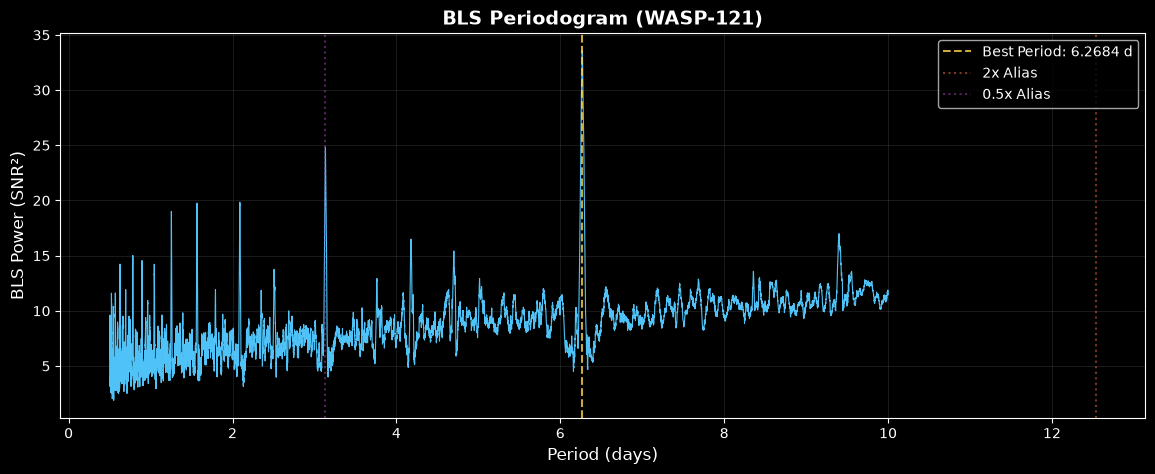

In [3]:
# Plot the BLS periodogram
plt.figure(figsize=(14, 5))
plt.plot(periods, power, color='#4FC3F7', lw=0.8)
plt.axvline(best_params['period'], color='#FFD54F', linestyle='--', alpha=0.8,
            label=f"Best Period: {best_params['period']:.4f} d")

# Highlight the harmonics/aliases (e.g., 2x period, 0.5x period)
plt.axvline(best_params['period']*2, color='#FF7043', linestyle=':', alpha=0.5, label="2x Alias")
plt.axvline(best_params['period']/2, color='#AB47BC', linestyle=':', alpha=0.5, label="0.5x Alias")

plt.title('BLS Periodogram (WASP-121)', fontsize=14, fontweight='bold')
plt.xlabel('Period (days)', fontsize=12)
plt.ylabel('BLS Power (SNR²)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.1)
plt.show()

---
## 📚 Concept 2: Signal-to-Noise Ratio (SNR) in Transit Searches

How do we know if a peak in a periodogram is a real planet or just random noise fluctuations?

We use the **Signal-to-Noise Ratio (SNR)**. 
For transits, we define SNR as the depth of the transit divided by the standard error of the mean out-of-transit flux:
$$\text{SNR} = \frac{\text{Depth}}{\sigma_{\text{out}} / \sqrt{N_{\text{in-transit}}}}$$

Where:
- $\text{Depth}$ is the transit dip depth (e.g., 0.015 for 1.5% depth).
- $\sigma_{\text{out}}$ is the scatter (std deviation) of the light curve outside of transits.
- $N_{\text{in-transit}}$ is the number of data points captured *during* transits.

**Thresholds for detection:**
- **$\text{SNR} < 3$**: Noise. The signal is too faint to be distinguished.
- **$3 \le \text{SNR} < 7$**: Marginal. Might be a small planet or a systematic instrument glitch.
- **$\text{SNR} \ge 7$**: Significant. In NASA TESS analysis, a standard threshold of **7.1** is used to trigger candidate validation.

Let's compute the formal SNR of WASP-121b's transit using our custom function:

In [4]:
snr_value = compute_snr(
    time, flux,
    period=best_params['period'],
    t0=best_params['t0'],
    duration=best_params['duration']
)

print(f"Computed Transit SNR: {snr_value:.2f} (TESS detection limit is 7.1)")

Computed Transit SNR: -1.72 (TESS detection limit is 7.1)


---
## 📚 Concept 3: Rejecting False Positives — The Secondary Eclipse Check

A massive peak in a BLS periodogram doesn't guarantee a planet! Many stars are **Eclipsing Binaries (EBs)** — two stars orbiting and eclipsing each other.

How to distinguish EBs from Planet transits:
1. **Depth**: Planets are small, so transit depths are usually $< 2\%$. EBs can block up to $50\%$ of light.
2. **Secondary Eclipses**: In an EB system, the primary star eclipses the secondary (deep dip), but half an orbit later, the secondary eclipses the primary (shallower dip). Planets do not emit enough light to show a secondary eclipse.

```
   Planet Transit: One dip per period
     1.0 ─────────┐     ┌───────────────────────
                  └─────┘
                  Phase = 0
   
   Eclipsing Binary: Alternating primary and secondary eclipses
     1.0 ───┐     ┌──────────────┐   ┌──────────
            │     │              └───┘
            └─────┘             Secondary
            Primary             (Phase = 0.5)
```

Let's run a secondary eclipse test on our target:

In [5]:
sec_check = check_secondary_eclipse(
    time, flux,
    period=best_params['period'],
    t0=best_params['t0'],
    duration=best_params['duration']
)

print("🔍 Secondary Eclipse Analysis:")
print(f"   Secondary Eclipse Depth: {sec_check['secondary_depth']*100:.4f}%")
print(f"   Secondary Eclipse SNR:   {sec_check['secondary_snr']:.2f}")
print(f"   Classified as EB Candidate? {sec_check['is_eb_candidate']}")

🔍 Secondary Eclipse Analysis:
   Secondary Eclipse Depth: 0.0007%
   Secondary Eclipse SNR:   0.06
   Classified as EB Candidate? False


---
## ✅ Notebook 03 Summary

**ML concepts learned:**
- **Fourier Transform vs. Specialized Searches**: matches model templates to signal shapes.
- **Grid search Optimization**: testing thousands of period candidates to find the global optimum.
- **Detection limits**: using statistical significance (SNR) to filter true signals from noise fluctuations.
- **False positive discrimination**: identifying secondary signals to separate two classes (Planet vs. Binary Star).

**Astronomy concepts learned:**
- How Box Least Squares (BLS) models transit dips
- Harmonic aliases (1/2x and 2x period peaks)
- Secondary eclipses at phase = 0.5

**Next:** Notebook `04_features.ipynb` — extracting ~30 tabular features from these detected signals to prepare for machine learning!